In [1]:
import pandas as pd
df = pd.read_csv("/content/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0

Outlier Detection using Boxplots:


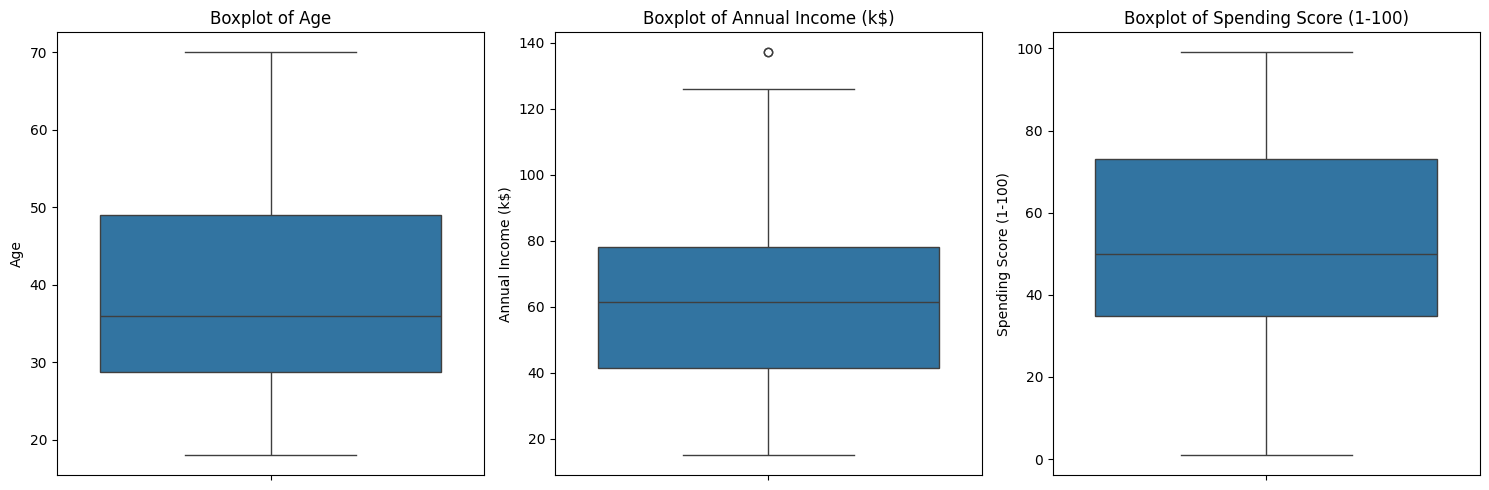


Outlier Detection using IQR Method:
Column 'Age': 0 outliers detected (rows: [])
Column 'Annual Income (k$)': 2 outliers detected (rows: [198, 199])
Column 'Spending Score (1-100)': 0 outliers detected (rows: [])


In [6]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Outlier detection using boxplots
print("Outlier Detection using Boxplots:")
plt.figure(figsize=(15, 5))
for i, column in enumerate(['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

# Outlier detection using IQR method
print("\nOutlier Detection using IQR Method:")
for column in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"Column '{column}': {len(outliers)} outliers detected (rows: {outliers.index.tolist()})")

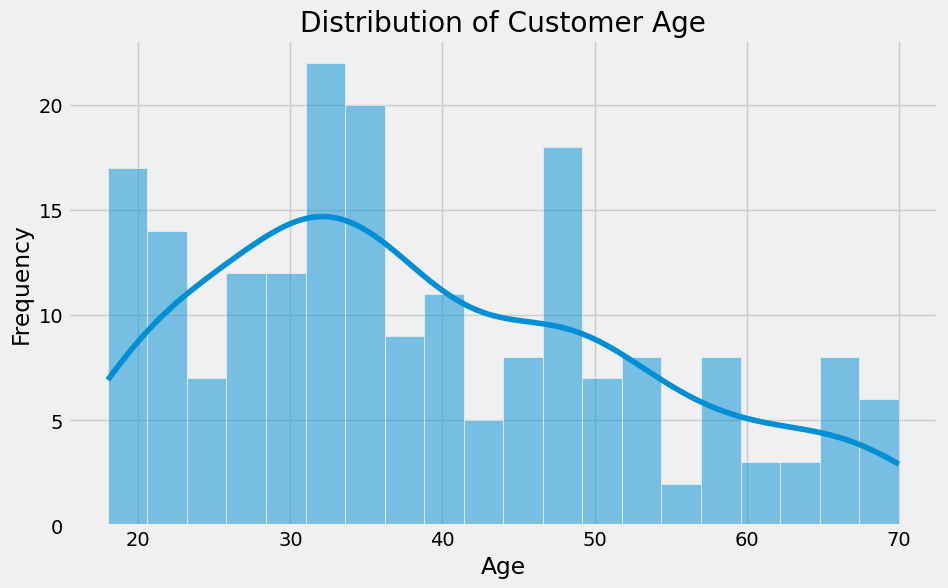

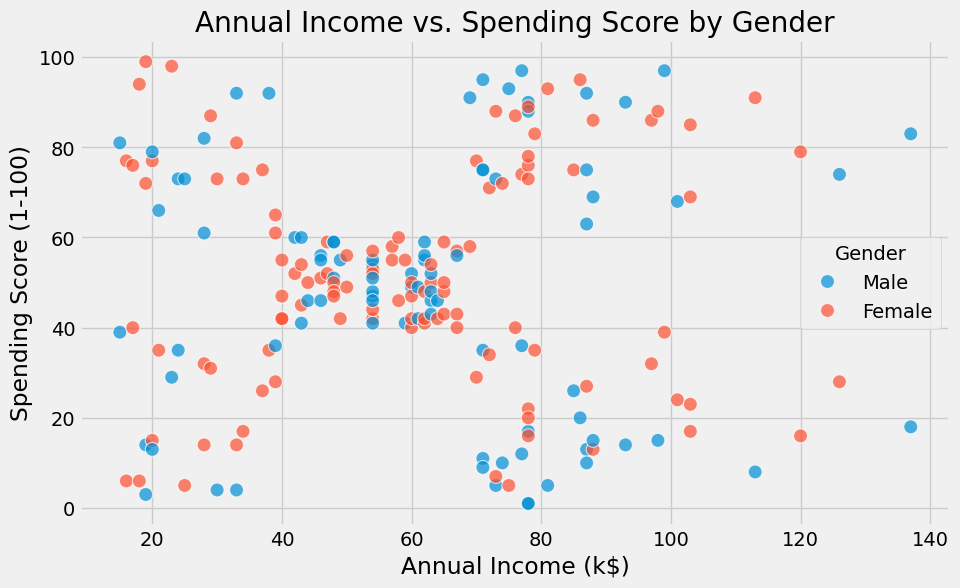

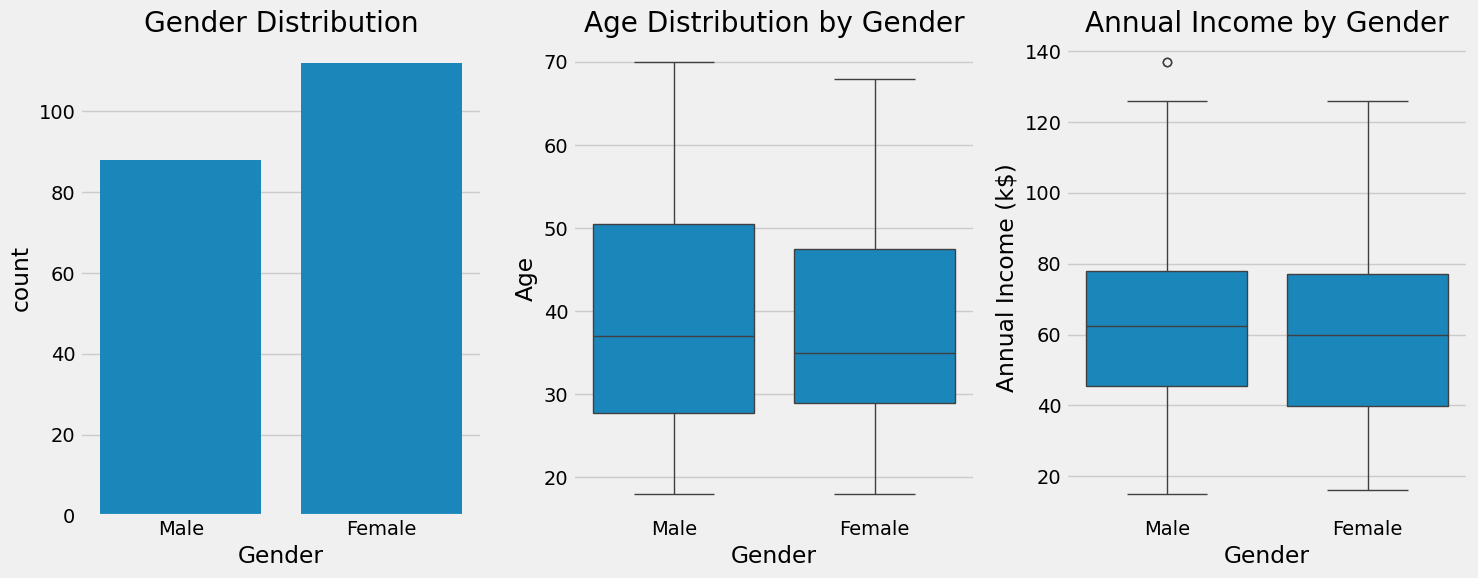

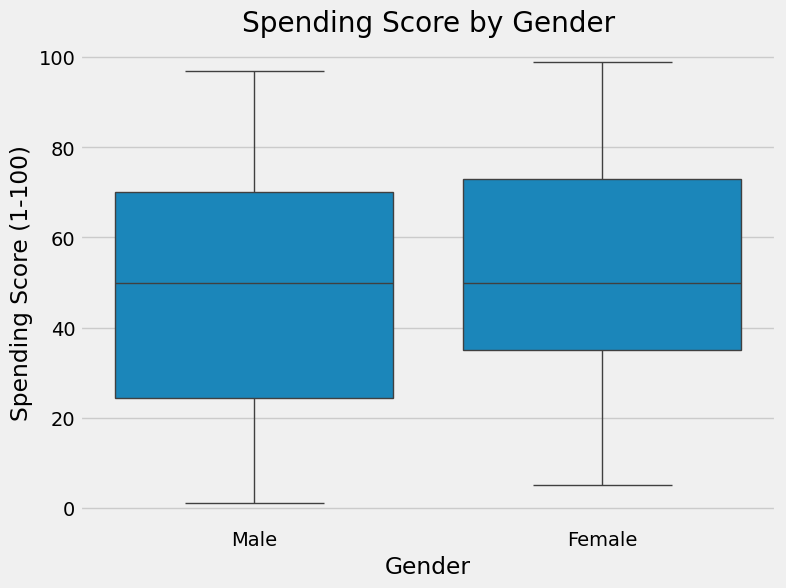

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

# 1. Customer Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# 2. Income vs. Spending Score
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df, hue='Gender', s=100, alpha=0.7)
plt.title('Annual Income vs. Spending Score by Gender')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Gender')
plt.show()

# 3. Gender-based Analysis
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')

plt.subplot(1, 3, 2)
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age Distribution by Gender')

plt.subplot(1, 3, 3)
sns.boxplot(x='Gender', y='Annual Income (k$)', data=df)
plt.title('Annual Income by Gender')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='Spending Score (1-100)', data=df)
plt.title('Spending Score by Gender')
plt.show()

In [8]:
# 1. Rename columns for better readability
df.rename(columns={'Annual Income (k$)': 'Annual Income', 'Spending Score (1-100)': 'Spending Score'}, inplace=True)
print('DataFrame columns renamed.')

# 2. Feature Engineering: Create 'Age Group'
bins = [18, 25, 35, 45, 55, 65, 70]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)
print('"Age Group" feature created.')

# 3. Feature Engineering: Create 'Spending Score Category'
bins_spending = [0, 20, 40, 60, 80, 100]
labels_spending = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['Spending Score Category'] = pd.cut(df['Spending Score'], bins=bins_spending, labels=labels_spending, right=False)
print('"Spending Score Category" feature created.')

# Display the DataFrame with new features
print('\nDataFrame head with new features:')
print(df.head())

DataFrame columns renamed.
"Age Group" feature created.
"Spending Score Category" feature created.

DataFrame head with new features:
   CustomerID  Gender  Age  Annual Income  Spending Score Age Group  \
0           1    Male   19             15              39     18-24   
1           2    Male   21             15              81     18-24   
2           3  Female   20             16               6     18-24   
3           4  Female   23             16              77     18-24   
4           5  Female   31             17              40     25-34   

  Spending Score Category  
0                     Low  
1               Very High  
2                Very Low  
3                    High  
4                  Medium  


In [9]:
df.to_csv('cleaned_mall_customers.csv', index=False)
print('Cleaned dataset saved to cleaned_mall_customers.csv')

Cleaned dataset saved to cleaned_mall_customers.csv
